In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import optim
from torch.utils.data import DataLoader
import optuna

In [3]:
%run MLdata.ipynb
%run MLfunc.ipynb   # from resources.MachineLearning import ...

# Multilayer Perceptrion (MLP)

## Model

In [4]:
class MLPhlayer(nn.Module):
    def __init__(self, in_size, out_size, norm=None):
        super(MLPhlayer, self).__init__()
        self.norm = norm
        self.fc = nn.Linear(in_size, out_size)
        self.act = nn.ReLU()
        if norm:
            self.norm = nn.LayerNorm(out_size)
    
    def forward(self, x):
        x = self.act(self.fc(x))
        if self.norm:
            x = self.norm(x)
        return x

class MLP(nn.Module):
    def __init__(self, in_size, h_size, out_size, norm=None):
        super(MLP, self).__init__()
        self.norm = norm
        self.fcIN = nn.Linear(in_size, h_size[0])
        self.fcOUT = nn.Linear(h_size[-1], out_size)
        self.act = nn.ReLU()
        if norm:
            self.normIN = nn.LayerNorm(h_size[0])
        self.dropout = nn.Dropout(0.25)
        self.hlayers = nn.Sequential(*[MLPhlayer(i, j, norm) for i, j in zip(h_size[:-1], h_size[1:])])

    def forward(self, x):
        x = self.act(self.fcIN(x))
        if self.norm:
            x = self.normIN(x)
        x = self.hlayers(x)
        return self.fcOUT(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


# Stress-Strain Curve Optimization
General approximation from change in node coordinate components to change in stress-strain curve.

In [5]:
in_size = train_in.shape[-1]
out_size = train_out.shape[-1]
h_size = [2**8]*4

BATCH_SIZE = 16
LEARNING_RATE = 9e-4
n_epochs = 2000

In [6]:
trainDS = Dataset_(train_in, train_outST)
valDS = Dataset_(val_in, val_outST)
testDS = Dataset_(test_in, test_outST)

train_dataloader = DataLoader(dataset=trainDS, batch_size=BATCH_SIZE, shuffle=True)
val_dataloader = DataLoader(dataset=valDS, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader = DataLoader(dataset=testDS, batch_size=BATCH_SIZE, shuffle=False)

In [7]:
mlp1 = MLP(in_size, h_size, out_size).to(device)
mlp1.apply(weights_init)
# print(torch.cuda.is_available())   ### TODO: GPU

opt = optim.Adam(mlp1.parameters(), lr=LEARNING_RATE)
lossf = nn.MSELoss()

earlyStop = EarlyStopping(patience=50, min_delta=1e-4, verbose=True)

ReduceLR = optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", factor=0.2427, patience=15, threshold=1e-4, verbose=True)
OneCycleLR = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=1e-3, steps_per_epoch=len(train_dataloader), epochs=n_epochs)
CosineAnnealingLR = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=n_epochs)

In [8]:
mlp1, epoch, train_lossLog, val_lossLog = train_model("mpl", mlp1, lossf, n_epochs, opt, train_dataloader, val_dataloader, scheduler=ReduceLR, earlyStop=earlyStop)

Epoch: 1 - Loss: 0.153675839304924
Epoch: 10 - Loss: 0.014774865470826626
Epoch: 20 - Loss: 0.006947777234017849
Epoch: 30 - Loss: 0.008291661739349365
Epoch: 40 - Loss: 0.006676006130874157
Epoch: 50 - Loss: 0.008446316234767437
Epoch 00052: reducing learning rate of group 0 to 9.7080e-06.
Epoch: 60 - Loss: 0.011973449029028416
Epoch 00068: reducing learning rate of group 0 to 2.3561e-06.
Epoch: 70 - Loss: 0.009044673293828964
Epoch: 80 - Loss: 0.006333473138511181
Early stopping triggered after 50 epochs without improvement.
Best Epoch: 72, with loss 0.003938155714422464


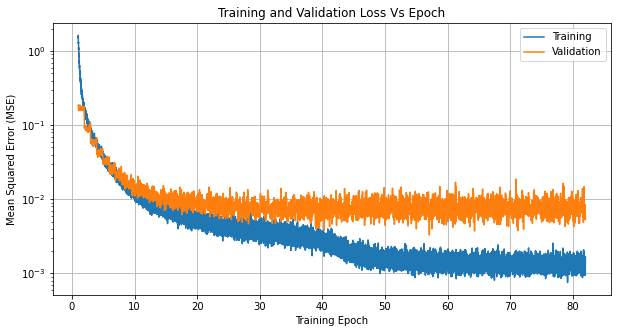

In [9]:
plot_loss(epoch, train_lossLog, val_lossLog)

In [10]:
test_outputs = predict_model("mlp", mlp1, test_dataloader)
test_outputs = standardize(test_outputs, outParams[0], outParams[1], mode=1)

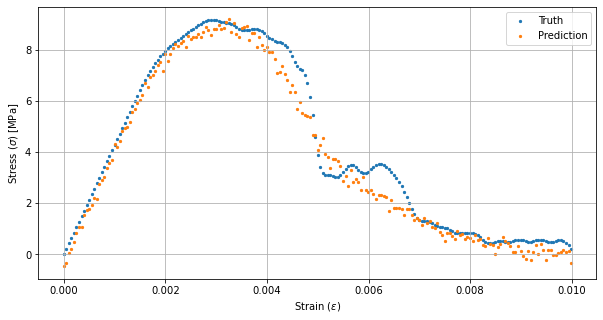

In [11]:
fig = plt.figure(figsize=(10, 5))
plt.scatter(perOUT[0], train_out[10]+perOUT[1], s=5, label="Truth")
plt.scatter(perOUT[0], test_outputs[10]+perOUT[1], s=5, label="Prediction")
plt.ylabel("Stress ($\sigma$) [MPa]")
plt.xlabel("Strain ($\epsilon$)")
plt.legend()
plt.grid()

In [12]:
err = list(abs(sum(test_out[:,60:140] - test_outputs[:,60:140])))
err.index(min(err)), err.index(max(err))

(6, 31)

# Distribution Function Optimization
Unique function approximations from perfect lattice coorindates to each disorder ($\Delta$) distribution.

### Version 1
$[x_i, y_i] \to \delta x_i$  
$[x_i, y_i] \to \delta y_i$

In [13]:
in_size = train_in1.shape[-1]
out_size = dx_out1.shape[-1]
h_size = [10, 100, 100, 10]

BATCH_SIZE = 1
LEARNING_RATE = 1e-3
n_epochs = 250

In [14]:
train_in1.shape, dx_out1.shape

((357, 2), (3583, 357, 1))

In [15]:
trainDS1x = Dataset_(train_in1ST, dx_out1[0])
trainDS1y = Dataset_(train_in1, dy_out1[0])

train1x_dataloader = DataLoader(dataset=trainDS1x, batch_size=BATCH_SIZE, shuffle=True)
train1y_dataloader = DataLoader(dataset=trainDS1y, batch_size=BATCH_SIZE, shuffle=True)

test1x_dataloader = DataLoader(dataset=trainDS1x, batch_size=BATCH_SIZE, shuffle=False)
test1y_dataloader = DataLoader(dataset=trainDS1y, batch_size=BATCH_SIZE, shuffle=False)

In [16]:
mlp2 = MLP(in_size, h_size, out_size).to(device)
mlp2.apply(weights_init)

opt = optim.Adam(mlp2.parameters(), lr=LEARNING_RATE)
lossf = nn.MSELoss()

earlyStop = EarlyStopping(patience=50, min_delta=1e-4, verbose=True)

ReduceLR = optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", factor=0.2427, patience=10, threshold=1e-4, verbose=True)
OneCycleLR = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=1e-3, steps_per_epoch=len(train1x_dataloader), epochs=n_epochs)
CosineAnnealingLR = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=n_epochs)

In [17]:
mlp2, epoch, train_lossLog, val_lossLog = train_model("mlp", mlp2, lossf, n_epochs, opt, train1x_dataloader, test1x_dataloader, scheduler=ReduceLR, earlyStop=earlyStop)

Epoch: 1 - Loss: 0.9642972946166992
Epoch: 10 - Loss: 0.8678528666496277
Epoch: 20 - Loss: 0.8066909313201904
Epoch: 30 - Loss: 0.773655116558075
Epoch: 40 - Loss: 0.7414395809173584
Epoch 00044: reducing learning rate of group 0 to 9.7080e-06.
Epoch: 50 - Loss: 0.7271342873573303
Epoch 00055: reducing learning rate of group 0 to 2.3561e-06.
Epoch: 60 - Loss: 0.7212817668914795
Epoch 00066: reducing learning rate of group 0 to 5.7183e-07.
Epoch: 70 - Loss: 0.7194227576255798
Epoch 00077: reducing learning rate of group 0 to 1.3878e-07.
Epoch: 80 - Loss: 0.7191631197929382
Early stopping triggered after 50 epochs without improvement.
Best Epoch: 82, with loss 0.7191244959831238


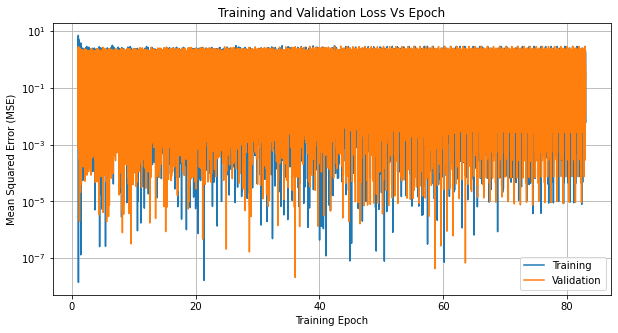

In [18]:
plot_loss(epoch, train_lossLog, val_lossLog)

In [19]:
test_outputs = predict_model("mlp", mlp2, test1x_dataloader)
max(test_outputs[:,0] - dx_out1[0,:,0])

1.7113999916954015

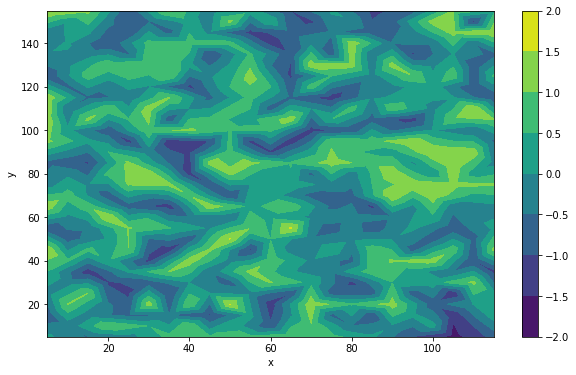

In [20]:
x_, y_ = train_in1[:,0], train_in1[:,1]
val_ = dx_out1[0,:,0] - test_outputs[:,0]

fig1 = plt.figure(figsize=(10, 6))
ax = fig1.add_subplot()
ax.set_xlabel('x')
ax.set_ylabel('y')
ctr = ax.tricontourf(x_, y_, val_, cmap="viridis")
plt.colorbar(ctr)

### Version 2
$[x_1, y_2, ..., x_n, y_n] \to [\delta x_i, ..., \delta x_n]$  
$[x_1, y_2, ..., x_n, y_n] \to [\delta y_i, ..., \delta y_n]$


In [21]:
train_in1_v2 = train_in1.flatten()
dx_out1_v2 = dx_out1[0].flatten()
dy_out1_v2 = dy_out1[0].flatten()
train_in1_v2.shape, dx_out1_v2.shape

((714,), (357,))

In [22]:
train_in1_v2 = np.array([train_in1_v2]*10)
dx_out1_v2 = np.array([dx_out1_v2]*10)
train_in1_v2.shape, dx_out1_v2.shape

((10, 714), (10, 357))

In [23]:
in_size = train_in1_v2.shape[-1]
out_size = dx_out1_v2.shape[-1]
h_size = [2**10]

BATCH_SIZE = 8
LEARNING_RATE = 9e-4
n_epochs = 10000

In [24]:
trainDS1x = Dataset_(train_in1_v2, dx_out1_v2)
trainDS1y = Dataset_(train_in1_v2, dy_out1_v2)

train1x_dataloader = DataLoader(dataset=trainDS1x, batch_size=BATCH_SIZE, shuffle=True)
train1y_dataloader = DataLoader(dataset=trainDS1y, batch_size=BATCH_SIZE, shuffle=True)

test1x_dataloader = DataLoader(dataset=trainDS1x, batch_size=BATCH_SIZE, shuffle=False)
test1y_dataloader = DataLoader(dataset=trainDS1y, batch_size=BATCH_SIZE, shuffle=False)

In [36]:
mlp3 = MLP(in_size, h_size, out_size).to(device)
mlp3.apply(weights_init)

opt = optim.Adam(mlp3.parameters(), lr=LEARNING_RATE)
lossf = nn.MSELoss()

earlyStop = EarlyStopping(patience=100, min_delta=1e-11, verbose=True)

ReduceLR = optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", factor=0.2427, patience=16, threshold=1e-4, verbose=True)
OneCycleLR = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=1e-3, steps_per_epoch=len(train1x_dataloader), epochs=n_epochs)
CosineAnnealingLR = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=n_epochs)

In [37]:
mlp3, epoch, train_lossLog, val_lossLog = train_model("mlp", mlp3, lossf, n_epochs, opt, train1x_dataloader, test1x_dataloader, scheduler=ReduceLR, earlyStop=earlyStop)

Epoch: 1 - Loss: 11084.5166015625
Epoch: 10 - Loss: 2253.8876953125
Epoch: 20 - Loss: 206.2394561767578
Epoch: 30 - Loss: 41.84956359863281
Epoch: 40 - Loss: 5.105996131896973
Epoch: 50 - Loss: 1.1604419946670532
Epoch: 60 - Loss: 0.7055193185806274
Epoch: 70 - Loss: 0.21716457605361938
Epoch: 80 - Loss: 0.038950301706790924
Epoch: 90 - Loss: 0.02642187289893627
Epoch: 100 - Loss: 0.00983847863972187
Epoch: 110 - Loss: 0.01142323762178421
Epoch: 120 - Loss: 0.01919032819569111
Epoch 00123: reducing learning rate of group 0 to 9.7080e-06.
Epoch: 130 - Loss: 0.0052376482635736465
Epoch: 140 - Loss: 0.0011461343383416533
Epoch: 150 - Loss: 0.0006661494262516499
Epoch: 160 - Loss: 0.0007231528288684785
Epoch: 170 - Loss: 0.0006169977132230997
Epoch 00174: reducing learning rate of group 0 to 2.3561e-06.
Epoch: 180 - Loss: 0.0002583495806902647
Epoch: 190 - Loss: 9.221771324519068e-05
Epoch: 200 - Loss: 3.6335699405753985e-05
Epoch: 210 - Loss: 7.21032774890773e-05
Epoch 00213: reducing lea

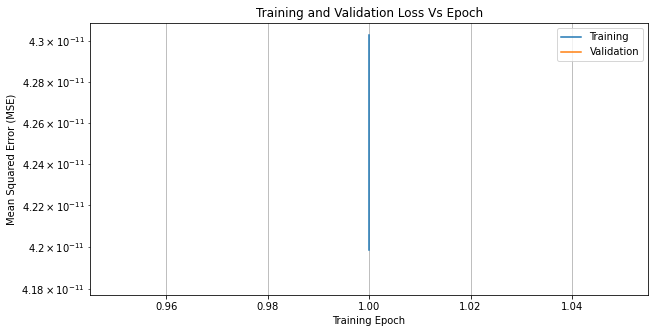

In [35]:
plot_loss(epoch, train_lossLog, val_lossLog)

In [38]:
test_outputs = predict_model("mlp", mlp3, test1x_dataloader)
max(abs(test_outputs[0] - dx_out1_v2[0])), min(abs(test_outputs[0] - dx_out1_v2[0]))

(2.474034652699686e-05, 1.548709610554866e-08)

In [39]:
dx_out1_v2.shape

(10, 357)

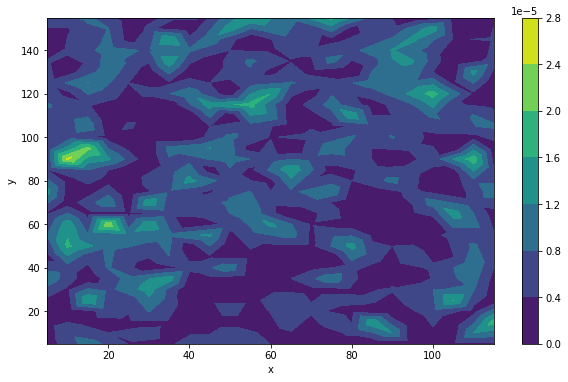

In [40]:
x_, y_ = train_in1[:,0], train_in1[:,1]
val_ = abs(dx_out1_v2[0] - test_outputs[0])

fig1 = plt.figure(figsize=(10, 6))
ax = fig1.add_subplot()
ax.set_xlabel('x')
ax.set_ylabel('y')
ctr = ax.tricontourf(x_, y_, val_, cmap="viridis")
plt.colorbar(ctr)

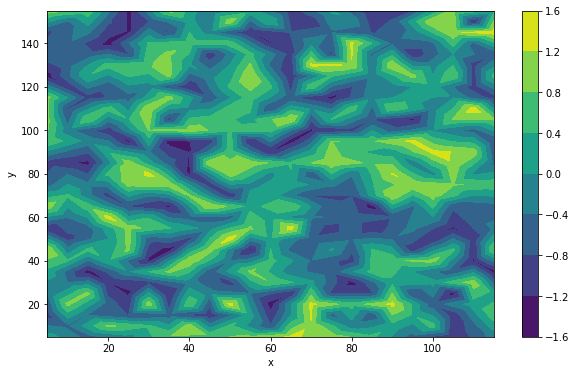

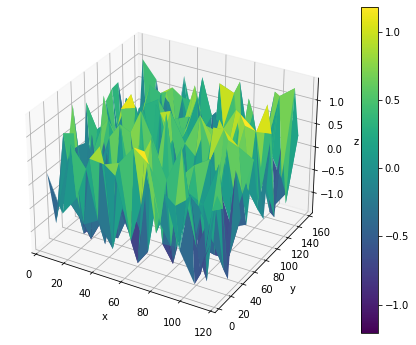

In [41]:
x_, y_ = train_in1[:,0], train_in1[:,1]
val_ = test_outputs[0]

fig2 = plt.figure(figsize=(10, 6))
ax = fig2.add_subplot()
ax.set_xlabel('x')
ax.set_ylabel('y')
ctr = ax.tricontourf(x_, y_, val_, cmap="viridis")
plt.colorbar(ctr)

fig3 = plt.figure(figsize=(10, 6))
ax = fig3.add_subplot(111, projection='3d')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ctr = ax.plot_trisurf(x_, y_, val_, cmap="viridis")
plt.colorbar(ctr)

In [42]:
for name, param in mlp3.state_dict().items():
    print(f"{name}: {param.shape}\n{param}\n")

fcIN.weight: torch.Size([1024, 714])
tensor([[ 0.0380, -0.0304, -0.0439,  ...,  0.0197,  0.0344, -0.0299],
        [-0.0749, -0.0015, -0.0727,  ...,  0.1036,  0.0322,  0.0486],
        [ 0.0241, -0.0003,  0.0067,  ..., -0.1259, -0.0238,  0.0340],
        ...,
        [ 0.0557, -0.0240,  0.0337,  ...,  0.0052, -0.0275,  0.0566],
        [ 0.0224,  0.0483,  0.0427,  ...,  0.0204, -0.0112, -0.0095],
        [-0.0649,  0.0452,  0.0232,  ...,  0.0465,  0.0200,  0.0291]])

fcIN.bias: torch.Size([1024])
tensor([ 0.0000,  0.0000, -0.0016,  ..., -0.0001,  0.0000,  0.0000])

fcOUT.weight: torch.Size([357, 1024])
tensor([[-0.1157,  0.0405, -0.0275,  ..., -0.0351, -0.0116,  0.0058],
        [-0.0318, -0.0010, -0.0123,  ..., -0.0448, -0.0167,  0.0429],
        [ 0.0676, -0.0205,  0.0253,  ...,  0.0432, -0.0821,  0.0271],
        ...,
        [ 0.0403,  0.0200,  0.0275,  ...,  0.0141, -0.0304, -0.1117],
        [-0.0679,  0.0336, -0.0695,  ...,  0.0276,  0.0022,  0.0216],
        [ 0.0251,  0.0401, 